In [108]:
# import packages
import numpy as np
import pandas as pd
import seaborn as sb
import glob 
import tensorflow
import keras

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-pastel')

Step 1: merge all the participant files from 1C

In [109]:
folder_path = "dfs_per_participant"
files = glob.glob(f"{folder_path}/*csv") #get name of all files in folder

dataframes = [] #list of all dataframes
for file in files:
    print('loading:', file)
    df = pd.read_csv(file)[:25] # return the first 25 rows
    dataframes.append(df)
full_df = pd.concat(dataframes, ignore_index=True) #merge the dataframes

min_len = full_df.groupby("id").size().min()
print(min_len)

loading: dfs_per_participant\df_AS14.01.csv
loading: dfs_per_participant\df_AS14.02.csv
loading: dfs_per_participant\df_AS14.03.csv
loading: dfs_per_participant\df_AS14.05.csv
loading: dfs_per_participant\df_AS14.06.csv
loading: dfs_per_participant\df_AS14.07.csv
loading: dfs_per_participant\df_AS14.12.csv
loading: dfs_per_participant\df_AS14.13.csv
loading: dfs_per_participant\df_AS14.14.csv
loading: dfs_per_participant\df_AS14.15.csv
loading: dfs_per_participant\df_AS14.16.csv
loading: dfs_per_participant\df_AS14.19.csv
loading: dfs_per_participant\df_AS14.23.csv
loading: dfs_per_participant\df_AS14.24.csv
loading: dfs_per_participant\df_AS14.25.csv
loading: dfs_per_participant\df_AS14.27.csv
loading: dfs_per_participant\df_AS14.28.csv
loading: dfs_per_participant\df_AS14.29.csv
loading: dfs_per_participant\df_AS14.30.csv
loading: dfs_per_participant\df_AS14.32.csv
loading: dfs_per_participant\df_AS14.33.csv
25


In [110]:
# avg_mood_target is now the target value instead of mood_class

full_df

,id,t,avg_mood_t,std_mood_t,trend_mood_t,avg_valence_t,std_valence_t,trend_valence_t,avg_arousal_t,std_arousal_t,trend_arousal_t,avg_screen_t,std_screen_t,trend_screen_t,target_day,avg_mood_target,std_mood_target,trend_mood_target
0,AS14.01,day 1-5,6.409091,0.650810,0.022021,0.545455,0.582102,0.009034,0.181818,0.935966,0.044043,89.034294,202.542435,-0.410834,day 6,6.000000,0.632456,1.000000e-01
1,AS14.01,day 2-6,6.347826,0.698364,-0.007905,0.391304,0.641949,-0.005929,0.391304,1.010343,0.034585,84.608197,186.752398,-0.155268,day 7,6.750000,0.829156,1.000000e-01
2,AS14.01,day 3-7,6.416667,0.759203,0.006087,0.416667,0.640095,-0.004348,0.458333,0.911920,0.015217,100.623293,264.562798,0.051103,day 8,6.600000,0.489898,-1.755417e-17
3,AS14.01,day 4-8,6.500000,0.763763,0.000000,0.500000,0.645497,-0.010435,0.375000,1.033300,-0.029130,90.594911,260.016018,0.122897,day 9,7.000000,0.000000,0.000000e+00
4,AS14.01,day 5-9,6.625000,0.695971,0.018696,0.541667,0.575845,0.010000,0.291667,1.059841,-0.025652,105.269426,394.646605,0.095235,day 10,6.400000,1.019804,4.000000e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
520,AS14.33,day 21-25,6.000000,1.799471,0.016883,0.380952,0.898474,0.019481,-0.142857,1.124858,-0.023377,241.682284,942.693021,0.853833,day 26,6.833333,0.897527,-2.857143e-02
521,AS14.33,day 22-26,6.500000,1.500000,-0.045737,0.545455,0.782030,-0.023715,-0.272727,1.212879,-0.007905,249.558570,1011.974409,1.096460,day 27,6.000000,0.000000,0.000000e+00
522,AS14.33,day 23-27,6.150000,1.194780,0.024812,0.450000,0.739932,0.011278,-0.200000,0.979796,-0.010526,200.982350,752.338781,-0.572464,day 28,7.000000,0.632456,-1.000000e-01
523,AS14.33,day 24-28,6.400000,1.113553,0.066165,0.600000,0.583095,0.042105,-0.100000,0.943398,0.039098,176.760246,706.388741,-0.913358,day 29,6.000000,1.224745,0.000000e+00


Step 3; split train/test set in a time-aware way
Since our rows are sequential windows per patient, the split should respect time and avoid training on future rows while testing on earlier ones. What “time-aware split” means here. For each participant separately: take the earlier rows for training, take the later rows for testing. Then do that for every participant, and combine all participant-level train parts into one training set and all test parts into one test set.

In [111]:
train_parts = [] #early data
test_parts = [] #later data
split_value = 0.8

for partcipant_id, group in full_df.groupby('id'):  #split dataset into groups based on id
    group = group.sort_values('target_day') #sort by target day
    split_idx = int(len(group) * split_value) #decide where to split
    
    train_group = group.iloc[:split_idx]
    test_group = group.iloc[split_idx:]

    train_parts.append(train_group)
    test_parts.append(test_group)

train_df = pd.concat(train_parts, ignore_index=True)
test_df = pd.concat(test_parts, ignore_index=True)

step 4; removing target leakage columns.
Target leakage = giving the model information it should not have at prediction time. As we try to predict next-day mood, the model should only see information from the past (window). Not anything from the target day. therefore we remove the target features from the dataframe, so we remove avg_mood_target, std_mood_target, trend_mood_target from the features. Additionally we remove id, t, and target_day as features.

In [112]:
cols_to_drop = [
# mood_target is not in there
    "avg_mood_target",     # leakage
    "std_mood_target",     # leakage
    "trend_mood_target",   # leakage
    # keep the id, to group
    "t",                   # not useful
    "target_day"           # future info
]

X_train = train_df.drop(columns=cols_to_drop) #training features
y_train = train_df[["id", "avg_mood_target"]]

X_test = test_df.drop(columns=cols_to_drop) #same as training features
y_test = test_df[["id", "avg_mood_target"]]


In [113]:
X_train

,id,avg_mood_t,std_mood_t,trend_mood_t,avg_valence_t,std_valence_t,trend_valence_t,avg_arousal_t,std_arousal_t,trend_arousal_t,avg_screen_t,std_screen_t,trend_screen_t
0,AS14.01,6.625000,0.695971,0.018696,0.541667,0.575845,0.010000,0.291667,1.059841,-0.025652,105.269426,394.646605,0.095235
1,AS14.01,6.541667,0.762625,0.026522,0.500000,0.707107,0.032174,0.125000,1.092112,-0.071739,104.600203,397.650623,0.005803
2,AS14.01,6.958333,0.888780,0.050000,0.708333,0.610953,0.020435,0.000000,0.957427,-0.020870,116.645267,438.770397,-0.077150
3,AS14.01,7.083333,0.862007,0.057391,0.750000,0.595119,0.012174,-0.166667,0.897527,-0.013043,105.809992,426.487896,0.062439
4,AS14.01,7.250000,0.829156,0.042609,0.750000,0.595119,-0.002609,-0.125000,0.832291,-0.008261,107.416231,447.261711,-0.000367
...,...,...,...,...,...,...,...,...,...,...,...,...,...
415,AS14.33,6.208333,1.632462,0.005652,0.416667,0.812233,0.020870,-0.333333,1.178511,-0.002609,206.287638,799.576047,1.056394
416,AS14.33,6.000000,1.799471,0.016883,0.380952,0.898474,0.019481,-0.142857,1.124858,-0.023377,241.682284,942.693021,0.853833
417,AS14.33,6.500000,1.500000,-0.045737,0.545455,0.782030,-0.023715,-0.272727,1.212879,-0.007905,249.558570,1011.974409,1.096460
418,AS14.33,6.150000,1.194780,0.024812,0.450000,0.739932,0.011278,-0.200000,0.979796,-0.010526,200.982350,752.338781,-0.572464


Make the tensors for input in RNN

In [114]:
from sklearn.preprocessing import StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Shape: (num_sequences, timesteps_per_sequence, 12)
X_train_tens = np.stack([group.values for _, group in X_train.groupby("id")])
X_train_tens = X_train_tens[:, :, 1:].astype(float) # drop id column
X_train_scaled = scaler_X.fit_transform(X_train_tens.reshape(-1, 12)).reshape(X_train_tens.shape)

X_test_tens = np.stack([group.values for _, group in X_test.groupby("id")])
X_test_tens = X_test_tens[:, :, 1:].astype(float) # drop id column
X_test_scaled = scaler_X.transform(X_test_tens.reshape(-1, 12)).reshape(X_test_tens.shape)

# Do the same for your target labels
y_train_tens = np.stack([group.values for _, group in y_train.groupby("id")])
y_train_tens = y_train_tens[:, :, 1:].astype(float) # drop id column
y_train_scaled = scaler_y.fit_transform(y_train_tens.reshape(-1,1)).reshape(21, 20, 1)

y_test_tens = np.stack([group.values for _, group in y_test.groupby("id")])
y_test_tens = y_test_tens[:, :, 1:].astype(float) # drop id column
y_test_scaled = scaler_y.transform(y_test_tens.reshape(-1,1)).reshape(21, 5, 1)

In [115]:
print(X_train_scaled.shape)
print(y_train_scaled.shape)

(21, 20, 12)
(21, 20, 1)


Start on RNN

In [116]:
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN, LSTM

In [117]:
def build_model(units = 32, learning_rate = 0.001):
    model = Sequential()
    model.add(LSTM(units, return_sequences=True))
    model.add(Dense(1)) # numerical/regression layer

    model.compile(optimizer= keras.optimizers.Adam(learning_rate=learning_rate),
              loss = 'mse',  # mean sqared error
              metrics = ['mse', 'mae']) # mean absolute error
    
    return model

In [118]:
model = build_model()

In [119]:
model.fit(X_train_scaled, y_train_scaled, epochs = 100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 1.1605 - mae: 0.8202 - mse: 1.1605
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 1.1259 - mae: 0.8068 - mse: 1.1259
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 1.0932 - mae: 0.7940 - mse: 1.0932
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 1.0622 - mae: 0.7820 - mse: 1.0622
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 1.0329 - mae: 0.7703 - mse: 1.0329
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 1.0053 - mae: 0.7589 - mse: 1.0053
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.9793 - mae: 0.7477 - mse: 0.9793
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.9548 - mae: 0.7373 - mse: 0.9548
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.9317 - mae: 0.7271 - mse: 0.9317
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.9101 - mae: 0.7174 - mse: 0.9101
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.8897 - mae

In [120]:
y_pred = model.predict(X_test_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step


In [121]:
# flatten and inverse scale data
y_pred_inv = scaler_y.inverse_transform(y_pred.reshape(-1,1))
y_pred_flat = y_pred_inv.flatten()
y_test_flat = y_test_tens.flatten()

In [122]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("MSE:", mean_squared_error(y_test_flat, y_pred_flat)) # average squared error, penalizes large errors
print("RMSE:", np.sqrt(mean_squared_error(y_test_flat, y_pred_flat))) # same unit as target?
print("MAE:", mean_absolute_error(y_test_flat, y_pred_flat)) # average absolut error, robust to outliers
print("R squared:", r2_score(y_test_flat, y_pred_flat)) # how much variance is explained, 1.0 = perfect

MSE: 0.5854892766509792
RMSE: 0.7651727103412531
MAE: 0.5437321892995682
R squared: 0.13980622746607152


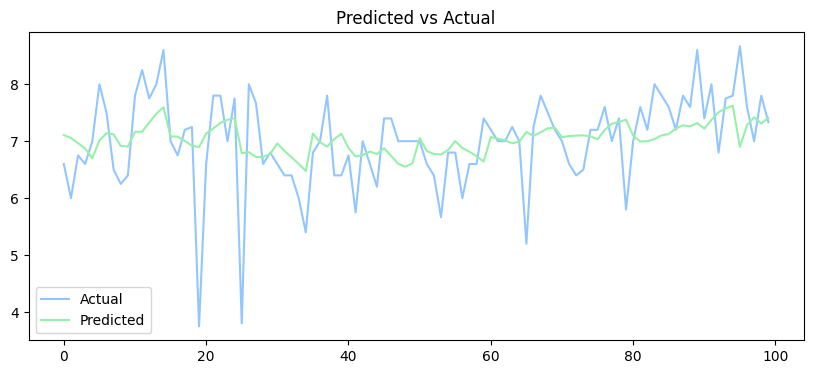

In [123]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(y_test_flat[:100], label='Actual')
plt.plot(y_pred_flat[:100], label='Predicted')
plt.legend()
plt.title('Predicted vs Actual')
plt.show()

In [124]:
# grid search

layer_units = [16, 32, 64]
learning_rates = [0.001, 0.01]

best_mse = 10000
best_params = {}

for units in layer_units:
    for learning_rate in learning_rates:
        # build model
        model = build_model(units = units, learning_rate=learning_rate) 

        # train
        history = model.fit(X_train_scaled, y_train_scaled, epochs = 100, verbose = 0)
        # print(history,summary)
        # evaluate
        mse = max(history.history['mse'])
        print(f"Units {units}, LR {learning_rate} -> MSE = {mse}")

        # Track best
        if mse < best_mse:
            best_mse = mse
            best_params = {'units' : units, 'learning_rate' : learning_rate}

print(f'Best params: {best_params}')
print(f'Best MSE: {best_mse:.4f}')

# grid_search = GridSearchCV(
#     estimator=model,
#     param_grid=param_grid,
#     cv=3, #Use 3-fold cross-validation
#     scoring="accuracy",
# )

# grid_search.fit(X_train_tens.reshape(21, -1), y_train_encoded.reshape(21,-1))
# print(grid_search.best_params_)
# print(grid_search.best_score_)

Units 16, LR 0.001 -> MSE = 0.9830693006515503
Units 16, LR 0.01 -> MSE = 1.2210031747817993
Units 32, LR 0.001 -> MSE = 1.0273876190185547
Units 32, LR 0.01 -> MSE = 0.910915195941925
Units 64, LR 0.001 -> MSE = 0.9533325433731079
Units 64, LR 0.01 -> MSE = 1.112382173538208
Best params: {'units': 32, 'learning_rate': 0.01}
Best MSE: 0.9109


In [127]:
# Build model
model = build_model(best_params['units'], best_params['learning_rate'])
model.fit(X_train_scaled, y_train_scaled, epochs = 100, verbose = 0)

# predict with model
y_pred = model.predict(X_test_scaled)


# flatten data
y_pred_inv = scaler_y.inverse_transform(y_pred.reshape(-1,1))
y_pred_flat = y_pred_inv.flatten()
y_test_flat = y_test_tens.flatten()

# get metrics
print("MSE:", mean_squared_error(y_test_flat, y_pred_flat)) # average squared error, penalizes large errors
print("RMSE:", np.sqrt(mean_squared_error(y_test_flat, y_pred_flat))) # same unit as target?
print("MAE:", mean_absolute_error(y_test_flat, y_pred_flat)) # average absolut error, robust to outliers
print("R squared:", r2_score(y_test_flat, y_pred_flat)) # how much variance is explained, 1.0 = perfect

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
MSE: 1.0702572146746472
RMSE: 1.0345323652136975
MAE: 0.7990672132703993
R squared: -0.5724089710723137


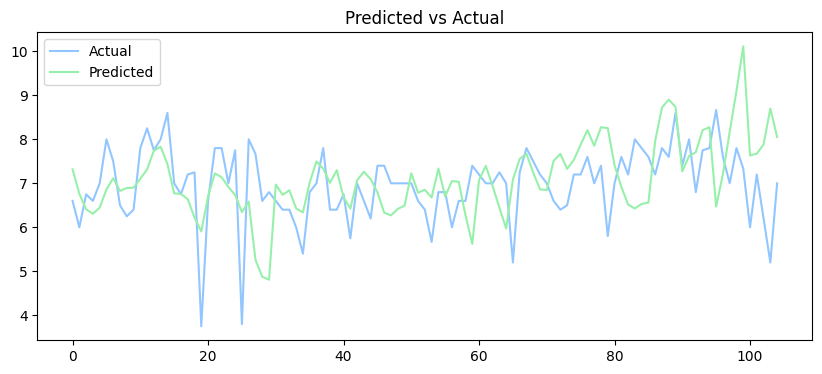

In [128]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(y_test_flat, label='Actual')
plt.plot(y_pred_flat, label='Predicted')
plt.legend()
plt.title('Predicted vs Actual')
plt.show()